In [2]:
import IPython
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path
import importlib
import inspect
import sys

project_root = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import torch 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pylab import multivariate_normal
import scipy

import SPDE.Fokker_Planck_ND as fp2d
importlib.reload(fp2d)
FokkerPlanck2D = fp2d.FokkerPlanck2D

2D SDE Simulation- Ornstein–Uhlenbeck:

$d\mathbf{X}_t = \mathbf{A} (\boldsymbol{\mu} - \mathbf{X}_t) dt + \boldsymbol\Sigma dW(t)$

In [39]:
def drift(t, x, params):
    A = params[0]   # shape (2, 2)
    mu = params[1]  # shape (2,)

    A = torch.as_tensor(A, dtype=torch.float32)
    mu = torch.as_tensor(mu, dtype=torch.float32)

    if x.ndim == 1:
        return A @ (mu - x)        # single trajectory, x shape (2,)
    else:
        return (mu - x) @ A.T      # many trajectories, x shape (M, 2)

def diffusion(t, x, params):
    Sigma = params[0] # shape (2,2)
    Sigma = torch.as_tensor(Sigma, dtype=torch.float32)
    return Sigma

def simulate_OU_2D(A, mu, Sigma, X0, Time, dt, no_trajectories, only_final_state=True):

    M = no_trajectories
    N = int(Time / dt)

    A = torch.as_tensor(A, dtype=torch.float32)
    mu = torch.as_tensor(mu, dtype=torch.float32)
    Sigma = torch.as_tensor(Sigma, dtype=torch.float32)
    X0 = torch.as_tensor(X0, dtype=torch.float32)

    t = torch.linspace(0, Time, N + 1)

    X_t = X0.repeat(M, 1)

    if only_final_state:

        for i in range(N):
            drift_term = drift(t[i], X_t, [A, mu])
            dW = torch.randn((M, 2), dtype=torch.float32) * (dt ** 0.5)
            noise_term = dW @ Sigma.T
            X_t = X_t + drift_term * dt + noise_term

        return t, X_t

    else:

        X = torch.zeros((M, N + 1, 2), dtype=torch.float32)
        X[:, 0, :] = X_t

        for i in range(N):
            X_t = X[:, i, :]
            drift_term = drift(t[i], X_t, [A, mu])
            dW = torch.randn((M, 2), dtype=torch.float32) * (dt ** 0.5)
            noise_term = dW @ Sigma.T
            X[:, i + 1, :] = X_t + drift_term * dt + noise_term

        return t, X


In [69]:
# Plot 2D OU process

parameters = [
    {
        "A": torch.tensor([[0.8, 0.3],
                           [0.1, 0.6]], dtype=torch.float32),
        "mu": torch.tensor([1.0, 2.0], dtype=torch.float32),
        "Sigma": torch.tensor([[0.5, 0.0],
                               [0.2, 0.4]], dtype=torch.float32)
    },

    {
        # Coupled drift with rotation-like behavior
        "A": torch.tensor([[0.70, -1.20],
                           [1.00,  0.70]], dtype=torch.float32),

        "mu": torch.tensor([0.0, 0.0], dtype=torch.float32),

        "Sigma": torch.tensor([[0.40, 0.00],
                               [0.15, 0.35]], dtype=torch.float32)
    },

    {
        # Strong anisotropic restoring force
        "A": torch.tensor([[1.50, 0.40],
                           [0.20, 0.50]], dtype=torch.float32),

        "mu": torch.tensor([2.0, -1.0], dtype=torch.float32),

        "Sigma": torch.tensor([[0.20, 0.10],
                               [0.00, 0.60]], dtype=torch.float32)
    },

    {
        # Weak drift, larger diffusion, broader cloud
        "A": torch.tensor([[0.25, 0.10],
                           [-0.05, 0.30]], dtype=torch.float32),

        "mu": torch.tensor([0.5, -0.5], dtype=torch.float32),

        "Sigma": torch.tensor([[0.70, 0.20],
                               [0.10, 0.70]], dtype=torch.float32)
    }



]

X0 = torch.tensor([0.0, 0.0])
Time = 10.0
dt = 0.001
no_trajectories = 2

 

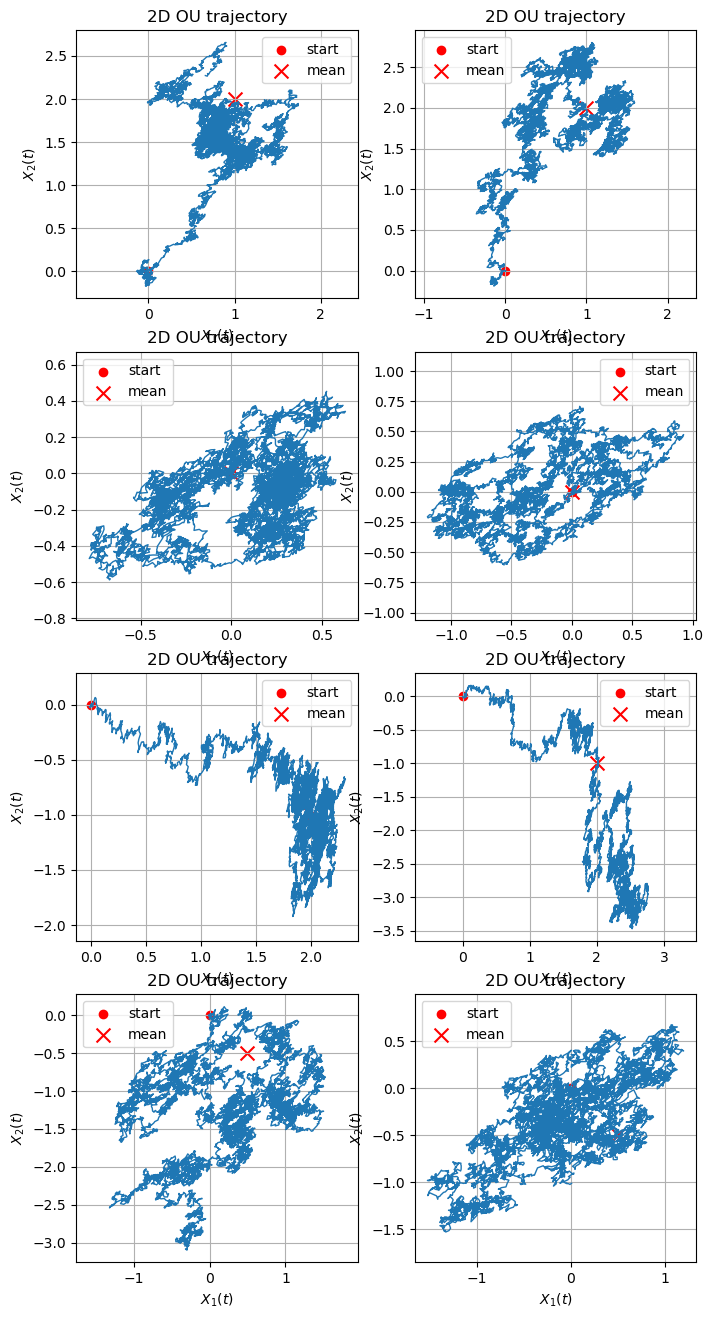

In [72]:

No_parameters = len(parameters)
fig, ax = plt.subplots(
    No_parameters,
    2,
    figsize=(8, 4 * No_parameters),
    squeeze=False
)
for idx, param in enumerate(parameters):

    t, X = simulate_OU_2D(parameters[idx]["A"], parameters[idx]["mu"], parameters[idx]["Sigma"], X0, Time, dt, no_trajectories, only_final_state=False)

    x1_0 = X[0, :, 0]
    x2_0 = X[0, :, 1]

    x1_1 = X[1, :, 0]
    x2_1 = X[1, :, 1]

    ax1 = ax[idx, 0]
    ax2 = ax[idx, 1]

    ax1.plot(x1_0, x2_0, linewidth=1)
    ax1.scatter(X0[0], X0[1], label="start", color="red")
    ax1.scatter(parameters[idx]["mu"][0], parameters[idx]["mu"][1], marker="x", s=100, label="mean", color="red")

    ax1.set_xlabel(r"$X_1(t)$")
    ax1.set_ylabel(r"$X_2(t)$")
    ax1.set_title("2D OU trajectory")
    ax1.legend()
    ax1.axis('equal')
    ax1.grid()

    ax2.plot(x1_1, x2_1, linewidth=1)
    ax2.scatter(X0[0], X0[1], label="start", color="red")
    ax2.scatter(parameters[idx]["mu"][0], parameters[idx]["mu"][1], marker="x", s=100, label="mean", color="red")

    ax2.set_xlabel(r"$X_1(t)$")
    ax2.set_ylabel(r"$X_2(t)$")
    ax2.set_title("2D OU trajectory")
    ax2.legend()
    ax2.axis('equal')
    ax2.grid()

plt.show()

In [148]:
# Long run simulation

burn_in_time = 1000
dt = 0.01
burn_in_steps = int(burn_in_time / dt)

t, X = simulate_OU_2D(parameters[0]["A"], parameters[0]["mu"], parameters[0]["Sigma"], X0, burn_in_time+1000, dt, no_trajectories = 1, only_final_state=False)

t_stationary = t[burn_in_steps:]
X_stationary = X[0, burn_in_steps:, :]

time_averaged_mean = torch.mean(X_stationary, dim=0)
time_averaged_Covariance = torch.cov(X_stationary.T)

print(f"Long-run mean: {time_averaged_mean}")
print(f"Long-run covariance: {time_averaged_Covariance}")


# Ensemble of trajectories

M = 10000
t, X_ensemble = simulate_OU_2D(parameters[0]["A"], parameters[0]["mu"], parameters[0]["Sigma"], X0, 1000, dt, no_trajectories = M, only_final_state=True)


mean_ensemble = torch.mean(X_ensemble, dim=0)
cov_ensemble = torch.cov(X_ensemble.T)

print(f"Ensemble mean: {mean_ensemble}")
print(f"Ensemble covariance: {cov_ensemble}")


# Analytical stationary distribution

A = parameters[0]["A"].numpy()
mu = parameters[0]["mu"].numpy()
Sigma = parameters[0]["Sigma"].numpy()
C = scipy.linalg.solve_continuous_lyapunov(A, Sigma @ Sigma.T)

print(f"Analytical stationary mean: {mu}")
print(f"Analytical stationary covariance: {C}")

print("Check Lyapunov residual:")
D = Sigma @ Sigma.T
residual = A @ C + C @ A.T - D
print(residual)

Long-run mean: tensor([0.9905, 2.0102])
Long-run covariance: tensor([[0.1455, 0.0250],
        [0.0250, 0.1578]])
Ensemble mean: tensor([1.0020, 1.9993])
Ensemble covariance: tensor([[0.1495, 0.0276],
        [0.0276, 0.1652]])
Analytical stationary mean: [1. 2.]
Analytical stationary covariance: [[0.14642857 0.02619048]
 [0.02619049 0.1623016 ]]
Check Lyapunov residual:
[[0.0000000e+00 1.4901161e-08]
 [2.2351742e-08 1.4901161e-08]]


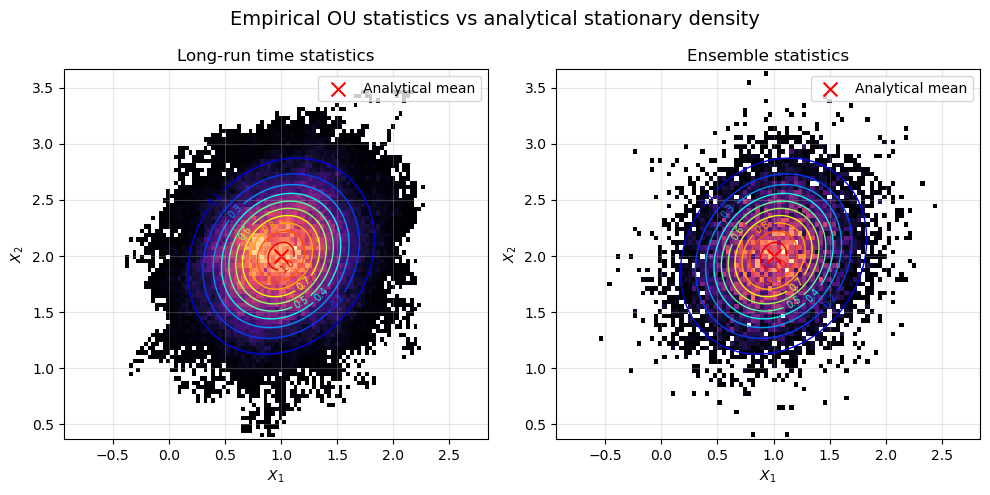

: 

In [ ]:

x_time_np = X_stationary.detach().cpu().numpy()
x_ens_np = X_ensemble.detach().cpu().numpy()

x1_min = min(x_time_np[:, 0].min(), x_ens_np[:, 0].min()) - 0.0
x1_max = max(x_time_np[:, 0].max(), x_ens_np[:, 0].max()) + 0.0

x2_min = min(x_time_np[:, 1].min(), x_ens_np[:, 1].min()) - 0.0
x2_max = max(x_time_np[:, 1].max(), x_ens_np[:, 1].max()) + 0.0

x1_grid = np.linspace(x1_min, x1_max, 150)
x2_grid = np.linspace(x2_min, x2_max, 150)

X1, X2 = np.meshgrid(x1_grid, x2_grid)

pos = np.dstack((X1, X2))

rv = scipy.stats.multivariate_normal(mean=mu, cov=C)
Z = rv.pdf(pos)

plt.figure(figsize=(10, 5), facecolor="white")

ax1 = plt.subplot(1, 2, 1)
ax1.set_facecolor("white")

h1 = ax1.hist2d(
    x_time_np[:, 0],
    x_time_np[:, 1],
    bins=80,
    density=True,
    cmap="magma",
    cmin=1e-12
)

c1 = ax1.contour(
    X1, X2, Z,
    levels=10,
    linewidths=1,
    cmap="jet"
)

ax1.scatter(mu[0], mu[1], marker="x", s=100, color="red", label="Analytical mean")
ax1.clabel(c1, inline=True, fontsize=7)

ax1.set_title("Long-run time statistics")
ax1.set_xlabel(r"$X_1$")
ax1.set_ylabel(r"$X_2$")
ax1.axis("equal")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right")


ax2 = plt.subplot(1, 2, 2)
ax2.set_facecolor("white")

h2 = ax2.hist2d(
    x_ens_np[:, 0],
    x_ens_np[:, 1],
    bins=80,
    density=True,
    cmap="magma",
    cmin=1e-12
)

c2 = ax2.contour(
    X1, X2, Z,
    levels=10,
    linewidths=1,
    cmap="jet"
)

ax2.scatter(mu[0], mu[1], marker="x", s=100, color="red", label="Analytical mean")
ax2.clabel(c2, inline=True, fontsize=7)

ax2.set_title("Ensemble statistics")
ax2.set_xlabel(r"$X_1$")
ax2.set_ylabel(r"$X_2$")
ax2.axis("equal")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")


plt.suptitle("Empirical OU statistics vs analytical stationary density", fontsize=14)
plt.tight_layout()
plt.show()